#Text Analysis
### Fordham Marketing Analytics Competition 2026

This notebook analyzes how caption text features drive engagement rate across 47 top Instagram creators (2022–2023). The analysis extracts quantitative features from post captions, computes engagement rate, and runs an OLS regression controlling for creator identity, genre, post format, and year.

In [ ]:
# Install vaderSentiment for sentiment score analysis
!pip install vaderSentiment openpyxl statsmodels -q

## 1. Load Data

In [ ]:
# Import pandas for data manipulation
import pandas as pd
import numpy as np

# Read in the cleaned dataset
df = pd.read_excel('/content/Updated - Cleaned Marketing Analytics Competition 2026 Dataset.xlsx')

# Group small genres (Food & Cooking, Science & Education) into Other
# These have too few posts to produce reliable findings on their own
small_genres = ['Food & Cooking', 'Science & Education']
df['genre_grouped'] = np.where(df['genre'].isin(small_genres), 'Other', df['genre'])

# Displaying shape and first 5 rows
print(df.shape)
df.head()

(5975, 13)


,account,username,followersatposting,postcreateddate,postcreatedtime,type,likes,comments,link,imagetext,postscraped,genre,genre_grouped
0,Marques Brownlee,mkbhd,3230521,2022-01-01,17:23:15,Album,303471,1744,https://www.instagram.com/p/CYMatrMLcQ4/,NaN,"13 years ago today, uploaded my first tech vid...",Tech,Tech
1,Chiara Ferragni ✨,chiaraferragni,25850439,2022-01-01,15:25:31,Photo,614091,1080,https://www.instagram.com/p/CYMNPe_IGMH/,NaN,A doll 🥰,Fashion & Beauty,Fashion & Beauty
2,Chiara Ferragni ✨,chiaraferragni,25850439,2022-01-01,12:57:56,Album,722257,833,https://www.instagram.com/p/CYL8Wb3oQz1/,NaN,Best of these days (end of 2021) and excited f...,Fashion & Beauty,Fashion & Beauty
3,Chiara Ferragni ✨,chiaraferragni,25846212,2022-01-01,00:06:41,Album,1430214,5314,https://www.instagram.com/p/CYKkFqHIj-Q/,NaN,Happy 2022 from The Ferragnez 💖,Fashion & Beauty,Fashion & Beauty
4,Drew Afualo,drewafualo,201285,2022-01-01,10:31:04,Album,62913,139,https://www.instagram.com/p/CYLriv1r_N2/,NaN,Happy new year to all u baddies ✨ 2021 was one...,Comedy,Comedy


## 2. Extract Text Features from Captions

We extract seven quantitative features from the postscraped caption column:
- **caption_length** — total character count
- **hashtag_count** — number of hashtags
- **emoji_count** — number of emojis
- **has_cta** — 1 if caption contains a call-to-action word, 0 if not
- **has_question** — 1 if caption contains a question mark, 0 if not
- **sentiment** — VADER score from -1 (very negative) to +1 (very positive)
- **has_tag** - 1 if caption contains an '@' symbol, 0 if not

In [ ]:
# Import re for pattern matching in text, and VADER for sentiment scoring
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Define a pattern that matches emoji characters using their Unicode ranges
emoji_pattern = re.compile(u"[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F9FF\u2600-\u26FF\u2700-\u27BF]+", flags=re.UNICODE)

# List of words/phrases we consider a call-to-action
cta_words = ['comment','tag','share','link in bio','swipe','click',
             'follow','save','dm me','tell me','let me know','drop']
# The 'tagged_creators' variable was defined but not used correctly. If the intent is to check for *any* '@' symbol,
# then a direct check like '@' in text is sufficient. Specific creator tags would require a list like ['@creator1', '@creator2']
# For now, we'll assume the intent is to check for the presence of the '@' symbol.

def extract_features(text):
    # If caption is empty or missing, return zeros for all features
    if pd.isna(text) or text == '':
        return pd.Series({'caption_length':0,'hashtag_count':0,'emoji_count':0,
                          'has_cta':0,'has_question':0,'sentiment':0, 'has_tag':0})

    text = str(text)
    return pd.Series({
        # Total number of characters in the caption
        'caption_length':  len(text),
        # Count words starting with # using pattern matching
        'hashtag_count':   len(re.findall(r'#\w+', text)),
        # Count emojis using the Unicode pattern defined above
        'emoji_count':     len(emoji_pattern.findall(text)),
        # 1 if any CTA word appears in caption, 0 if not - using list comprehension here
        'has_cta':         int(any(w in text.lower() for w in cta_words)),
        # 1 if caption contains a question mark, 0 if not
        'has_question':    int('?' in text),
        # VADER sentiment score: -1 (very negative) to +1 (very positive)
        'sentiment':       analyzer.polarity_scores(text)['compound'],
        # 1 if caption contains the '@' symbol (indicating a tag), 0 if not
        'has_tag':         int('@' in text) # Checks for presence of '@' in the text
    })

# Run extract_features on every row in postscraped, then assign new columns to df
# This will overwrite existing columns with the same names, avoiding duplicates
new_features_df = df['postscraped'].apply(extract_features)

# Assign new features column by column to robustly handle potential duplicate column names in df
for col in new_features_df.columns:
    df[col] = new_features_df[col]

df[['postscraped','caption_length','hashtag_count','emoji_count','has_cta','has_question','sentiment', 'has_tag']].head()


,postscraped,caption_length,hashtag_count,emoji_count,has_cta,has_question,sentiment,has_tag
0,"13 years ago today, uploaded my first tech vid...",124.0,0.0,0.0,0.0,0.0,0.6608,0.0
1,A doll 🥰,8.0,0.0,1.0,0.0,0.0,0.8074,0.0
2,Best of these days (end of 2021) and excited f...,60.0,0.0,1.0,0.0,0.0,0.9186,0.0
3,Happy 2022 from The Ferragnez 💖,31.0,0.0,1.0,0.0,0.0,0.8779,0.0
4,Happy new year to all u baddies ✨ 2021 was one...,242.0,1.0,1.0,1.0,1.0,0.9869,0.0


## 3. Add Engagement Rate

In [ ]:
# Engagement rate = likes + comments divided by follower count at time of posting
# This normalizes for audience size so we can fairly compare across creators
df['engagement_rate'] = (df['likes'] + df['comments']) / df['followersatposting']

df[['account','likes','comments','followersatposting','engagement_rate']].head()

,account,likes,comments,followersatposting,engagement_rate
0,Marques Brownlee,303471,1744,3230521,0.094479
1,Chiara Ferragni ✨,614091,1080,25850439,0.023797
2,Chiara Ferragni ✨,722257,833,25850439,0.027972
3,Chiara Ferragni ✨,1430214,5314,25846212,0.055541
4,Drew Afualo,62913,139,201285,0.313247


## 4. Descriptive Statistics

In [ ]:
# Group hashtag counts into buckets to find the sweet spot
# pd.cut divides hashtag_count into labeled ranges based on the bins we define
df['hashtag_bucket'] = pd.cut(df['hashtag_count'], bins=[-1,0,2,5,10,100],
                               labels=['0','1-2','3-5','6-10','10+'])

print('Engagement rate by hashtag count')
print(df.groupby('hashtag_bucket', observed=False)['engagement_rate'].agg(['mean','median','count']))

# Sweet spot at 6-10 hashtags (mean engagement rate = 0.116), drops sharply at 10+ (mean engagement rate = 0.038)

Engagement rate by hashtag count
                    mean    median  count
hashtag_bucket                           
0               0.067623  0.031452   4620
1-2             0.079516  0.032502    968
3-5             0.091683  0.019009    230
6-10            0.115520  0.070697     96
10+             0.038358  0.009653     61


## 5. Time Control

We add a binary variable for year to control for any Instagram changes between 2022 and 2023.

In [ ]:
# Extract year from date column — 0 for 2022 posts, 1 for 2023 posts
df['is_2023'] = (pd.to_datetime(df['postcreateddate']).dt.year == 2023).astype(int)

print(df['is_2023'].value_counts())

is_2023
0    3260
1    2715
Name: count, dtype: int64


## 6. OLS Regression Model

We run OLS regression predicting engagement rate from text features, controlling for:
- **Creator fixed effects** — accounts for baseline differences between creators
- **Post format** — album vs video vs photo
- **Year** — accounts for platform changes between 2022 and 2023

Baseline categories: Photo (post format), 2022 (year)

Genre is discussed descriptively rather than included in the regression, since each creator belongs to exactly one genre, creator fixed effects already capture genre-level differences. Including both caused severe multicollinearity (condition number was 1.15e+16).

In [ ]:
import statsmodels.api as sm

# Post format dummies
# Convert post type to binary columns (1 = yes, 0 = no)
# Photo is the baseline, album and video are compared against it
df['is_album'] = (df['type'] == 'Album').astype(int)
df['is_video'] = (df['type'] == 'Video').astype(int)

# Creator fixed effects
# One dummy column per creator, accounts for each creator's baseline engagement rate
# drop_first=True drops one creator to use as the reference point
creator_dummies = pd.get_dummies(df['account'], prefix='creator', drop_first=True).astype(int)

# Text features
text_features = ['caption_length', 'hashtag_count', 'emoji_count',
                 'has_cta', 'has_question', 'sentiment', 'has_tag']

# Control variables
controls = ['is_2023', 'is_album', 'is_video']

df_reg = df[text_features + controls + ['engagement_rate']].dropna()

# Combine text features + controls + creator dummies
X = pd.concat([df_reg[text_features + controls], creator_dummies.loc[df_reg.index]], axis=1)

# Add a constant and fit the OLS model
X = sm.add_constant(X)
model = sm.OLS(df_reg['engagement_rate'], X).fit()

print(model.summary())

# Findings:
# caption_length - coef=+0.0000, p=0.007 - longer captions drive slightly higher engagement
# hashtag_count - coef=-0.0014, p=0.015 - each additional hashtag reduces engagement rate
# is_2023 - coef=-0.0183, p<0.001 - engagement dropped platform-wide in 2023
# is_album - coef=+0.0103, p<0.001 - carousels outperform photos
# is_video - coef=-0.0462, p<0.001 - videos underperform photos significantly
# not significant: has_cta, has_question, sentiment, emoji_count

                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     171.0
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:33:59   Log-Likelihood:                 8112.6
No. Observations:                5975   AIC:                        -1.611e+04
Df Residuals:                    5918   BIC:                        -1.573e+04
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

## 7. VIF Check — Multicollinearity Diagnostic


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Run VIF on text features and controls only
# We exclude creator dummies, they are fixed effects, not predictors of interest
# Rule of thumb: VIF > 4 is concerning
X_vif = sm.add_constant(df_reg[text_features + controls])

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("VIF values for text features and controls:")
display(vif_data)

# All VIF values below 2 — no multicollinearity concern among predictors of interest
# The large condition number in the regression output is likely driven by the 46 creator dummy columns, not by collinearity among our text features

VIF values for text features and controls:


,feature,VIF
0,const,6.797109
1,caption_length,1.453877
2,hashtag_count,1.078670
3,emoji_count,1.156715
4,has_cta,1.239602
5,has_question,1.035732
6,sentiment,1.216496
7,has_tag,1.205761
8,is_2023,1.033867
9,is_album,1.111372


## 8. Accounting for Heteroscedasticity:

Below a residual plot reveals that the spread of residuals increases as fitted values increase confirming that heteroscedasticity is present

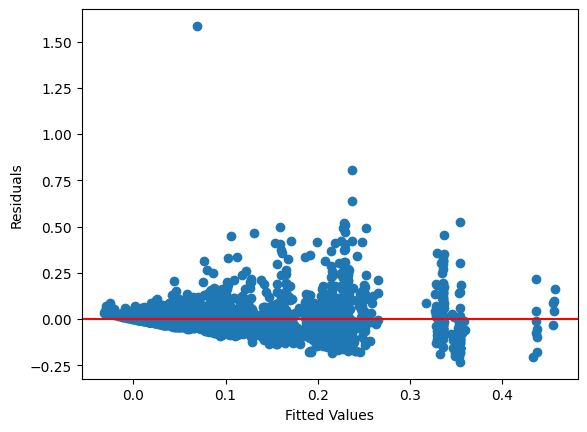

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

One line is added to the original OLS mode, (cov_type='HC3') which corrects for non-constant variance in residuals without changing coefficients

In [ ]:
# Define y and X_sm from the previous regression setup
y = df_reg['engagement_rate']
X_sm = X

# Original OLS model (already have this)
model_ols = sm.OLS(y, X_sm).fit()

# HC3 Robust model - one line change
model_hc3 = sm.OLS(y, X_sm).fit(cov_type='HC3')

# Print both summaries
print("=== ORIGINAL OLS ===")
print(model_ols.summary())

print("=== HC3 ROBUST ===")
print(model_hc3.summary())

=== ORIGINAL OLS ===
                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     171.0
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:34:00   Log-Likelihood:                 8112.6
No. Observations:                5975   AIC:                        -1.611e+04
Df Residuals:                    5918   BIC:                        -1.573e+04
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 56, but rank is 55
  warnings.warn('covariance of constraints does not have full '
